# Notebook reorganizing aux files 

In [63]:
import xarray as xr 

### Reduced basis aux file 

In [64]:
ds_red_basis = xr.open_dataset("./aux_reduced_basis_BM.nc")

In [65]:
lon_min = 185; lon_max = 205
lat_min = 15; lat_max= 35

In [66]:
ds_red_basis = ds_red_basis.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))

In [67]:
ds_red_basis.to_netcdf("aux_reduced_basis_BM_new.nc")

In [68]:
ds_red_basis

<xarray.Dataset> Size: 247kB
Dimensions:  (lon: 21, lat: 21, f: 70)
Coordinates:
  * lon      (lon) float32 84B 185.0 186.0 187.0 188.0 ... 203.0 204.0 205.0
  * lat      (lat) float32 84B 15.0 16.0 17.0 18.0 19.0 ... 32.0 33.0 34.0 35.0
  * f        (f) float32 280B 0.001005 0.00201 0.003015 ... 0.06935 0.07035
Data variables:
    Std      (f, lat, lon) float32 123kB ...
    Tdec     (f, lat, lon) float32 123kB ...

### Bathymetry file

In [29]:
bathy = xr.open_dataset("/bettik/bellemva/sad/Bathymetry_hawai.nc")

In [30]:
ds_QGSW = xr.open_dataset("/bettik/bellemva/ocean_data_challenge/2023e_SSHmapping_HF_Hawaii/dc_ref_eval_coarse/2023e_SSHmapping_HF_Hawaii_eval_2012-08-27.nc")
# - BALANCED MOTIONS BM - #
ds_QGSW = ds_QGSW.assign_coords(
    longitude=((ds_QGSW.longitude + 180) % 360) - 180
).sortby("longitude")
ssh_bm_QGSW = ds_QGSW.ssh_bm.load()
ssh_bm_QGSW = ssh_bm_QGSW.rename({"longitude":"lon","latitude":"lat"})

In [31]:
bathy = bathy.interp_like(ssh_bm_QGSW)

In [32]:
bathy = bathy.load()

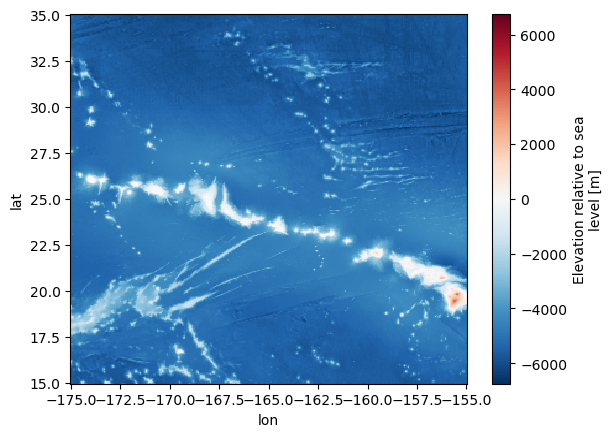

In [33]:
bathy.elevation.plot()

In [36]:
bathy.to_netcdf("./Bathymetry_hawaii.nc")

### FES files

In [69]:
lon_min = 185; lon_max = 205
lat_min = 15; lat_max= 35

Target grid

In [70]:
ds_QGSW = xr.open_dataset("/bettik/bellemva/ocean_data_challenge/2023e_SSHmapping_HF_Hawaii/dc_ref_eval_coarse/2023e_SSHmapping_HF_Hawaii_eval_2012-08-27.nc")
# - BALANCED MOTIONS BM - #
ssh_bm_QGSW = ds_QGSW.ssh_bm.load()
ssh_bm_QGSW = ssh_bm_QGSW.rename({"longitude":"lon","latitude":"lat"})

In [71]:
m2_e = xr.open_dataset("/bettik/bellemva/FES_tide/eastward_velocity/m2.nc")
m2_n = xr.open_dataset("/bettik/bellemva/FES_tide/northward_velocity/m2.nc")

n2_e = xr.open_dataset("/bettik/bellemva/FES_tide/eastward_velocity/n2.nc")
n2_n = xr.open_dataset("/bettik/bellemva/FES_tide/northward_velocity/n2.nc")

s2_e = xr.open_dataset("/bettik/bellemva/FES_tide/eastward_velocity/s2.nc")
s2_n = xr.open_dataset("/bettik/bellemva/FES_tide/northward_velocity/s2.nc")

In [72]:
m2_e = m2_e.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max),drop=True)
m2_n = m2_n.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max),drop=True)

n2_e = n2_e.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max),drop=True)
n2_n = n2_n.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max),drop=True)

s2_e = s2_e.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max),drop=True)
s2_n = s2_n.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max),drop=True)

In [76]:
m2_e.to_netcdf("/home/bellemva/Bellemin-Laponnaz_2026_JAMES/mapping/aux/FES_tide/eastward_velocity/m2.c")
m2_n.to_netcdf("/home/bellemva/Bellemin-Laponnaz_2026_JAMES/mapping/aux/FES_tide/northward_velocity/m2.c")

n2_e.to_netcdf("/home/bellemva/Bellemin-Laponnaz_2026_JAMES/mapping/aux/FES_tide/eastward_velocity/n2.c")
n2_n.to_netcdf("/home/bellemva/Bellemin-Laponnaz_2026_JAMES/mapping/aux/FES_tide/northward_velocity/n2.c")

s2_e.to_netcdf("/home/bellemva/Bellemin-Laponnaz_2026_JAMES/mapping/aux/FES_tide/eastward_velocity/s2.c")
s2_n.to_netcdf("/home/bellemva/Bellemin-Laponnaz_2026_JAMES/mapping/aux/FES_tide/northward_velocity/s2.c")